In [ ]:
#Importing Dataset And changing to CSV format 
# Downloaded fromt th Openml it's in arff format (Attribute-Relation File Format)
import os
from scipy.io import arff
import pandas as pd
current_dir=os.getcwd()
Bas_dir=os.path.dirname(current_dir)
data_path=os.path.join(Bas_dir,"data","dataset_.arff")
data,meta=arff.loadarff(data_path)
df=pd.DataFrame(data)




FileNotFoundError: [Errno 2] No such file or directory: 'd:\\my_git\\Diabetes_Classification\\Notebook\\data\\dataset_.arff'

In [5]:
# converting to CSV and save 
df.to_csv("D:\my_git\Diabetes_Classification\Data\diabetes.csv",index=False)

<>:2: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:2: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\Seetharaman\AppData\Local\Temp\ipykernel_27768\2753284654.py:2: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  df.to_csv("D:\my_git\Diabetes_Classification\Data\diabetes.csv",index=False)


In [6]:
#importing the csv filter
df=pd.read_csv(r"D:\my_git\Diabetes_Classification\Data\diabetes.csv")

# EDA

In [7]:
# Importing necessary libraries 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [8]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    float64
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    float64
 8   Outcome                   768 non-null    float64
dtypes: float64(9)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
#Checking for invalid zeros
col_zero=['Glucose','BloodPressure','SkinThickness','Insulin','BMI'] #These column can't be zero so checking if any patients have zero by mistake
for col in col_zero:
    print(f"{col}: {(df[col]==0).sum()}")

Glucose: 0
BloodPressure: 0
SkinThickness: 0
Insulin: 0
BMI: 0


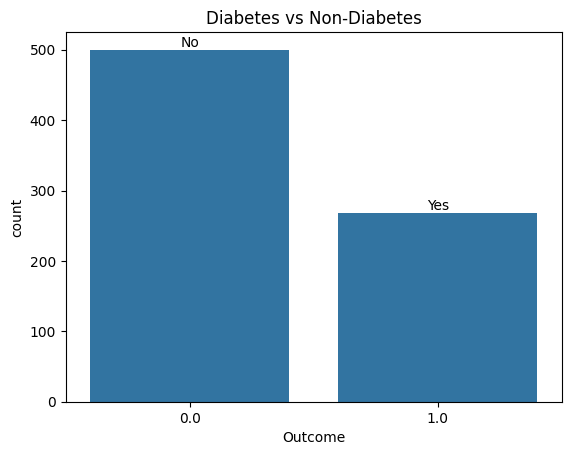

In [10]:
#The diabetics yes or no distribution
ax=sns.countplot(x='Outcome', data=df)
ax.bar_label(ax.containers[0],labels=['No','Yes'])
plt.title("Diabetes vs Non-Diabetes")
plt.show()

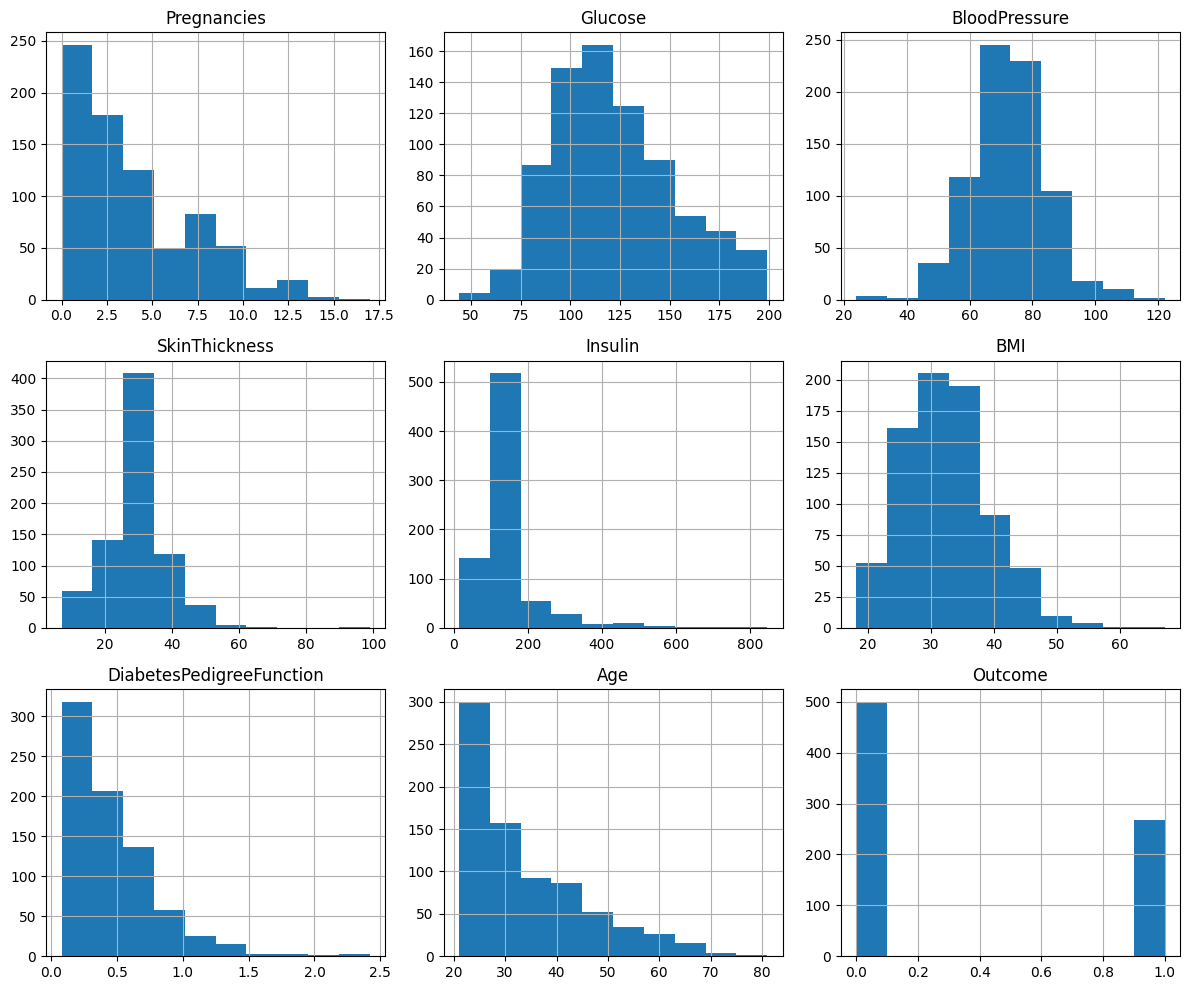

In [11]:
# Feature distributions
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()



Histogram insight
 - Histogram analysis was performed to understand the distribution of each feature. It was observed that features like Glucose and BloodPressure are approximately centered with slight skewness. Insulin shows a right-skewed distribution, indicating the presence of some higher extreme values. The Age distribution suggests that most individuals in the dataset fall within a younger to middle-aged range.

C:\Users\Seetharaman\AppData\Local\Temp\ipykernel_27768\1100905863.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Diabetes', 'Diabetes'])


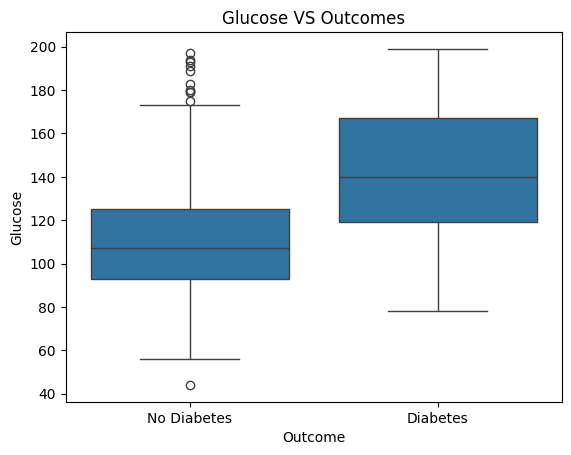

C:\Users\Seetharaman\AppData\Local\Temp\ipykernel_27768\1100905863.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Diabetes', 'Diabetes'])


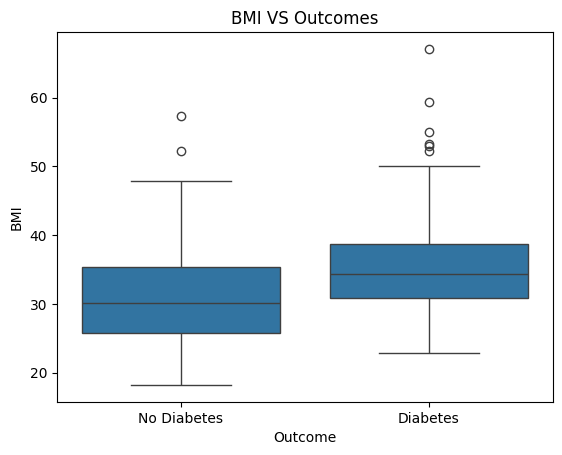

C:\Users\Seetharaman\AppData\Local\Temp\ipykernel_27768\1100905863.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Diabetes', 'Diabetes'])


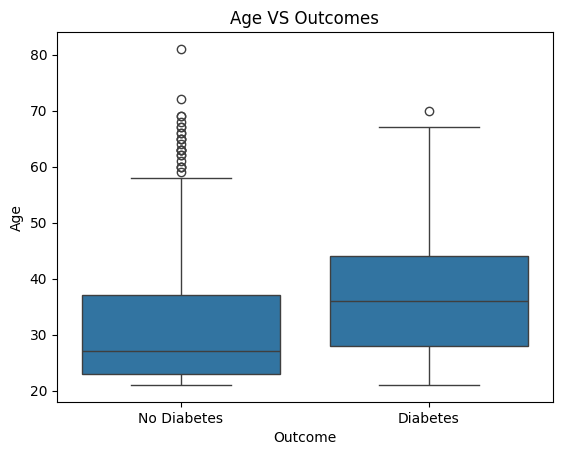

C:\Users\Seetharaman\AppData\Local\Temp\ipykernel_27768\1100905863.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Diabetes', 'Diabetes'])


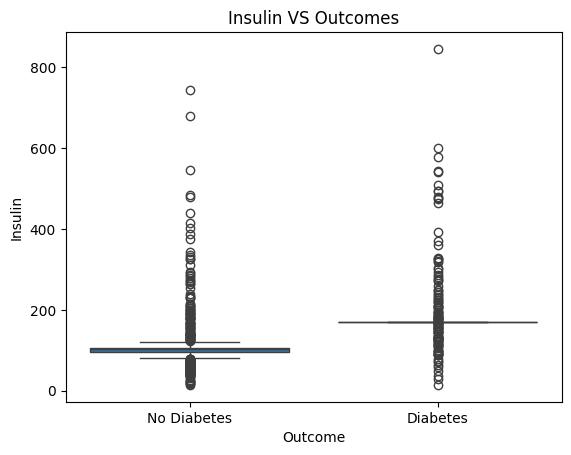

In [12]:
# Compared the features with Outcomes
features=['Glucose', 'BMI', 'Age', 'Insulin']
for feat in features:
    ax=sns.boxplot(x='Outcome', y=feat, data=df)
    plt.title(f"{feat} VS Outcomes")
    ax.set_xticklabels(['No Diabetes', 'Diabetes'])
    plt.show()

Feature wise insight 
- Glucose:
    - Glucose levels are significantly higher in diabetic patients compared to non-diabetic patients, indicating that it is a strong predictor of diabetes.
- BMI
    - BMI values are slightly higher for diabetic patients, suggesting a relationship between higher body weight and diabetes risk.
- Age
    - Diabetic patients tend to be older on average compared to non-diabetic individuals, indicating age as a contributing factor
- Insulin
    - Insulin levels show higher variability among diabetic patients, although the relationship is less consistent compared to Glucose.

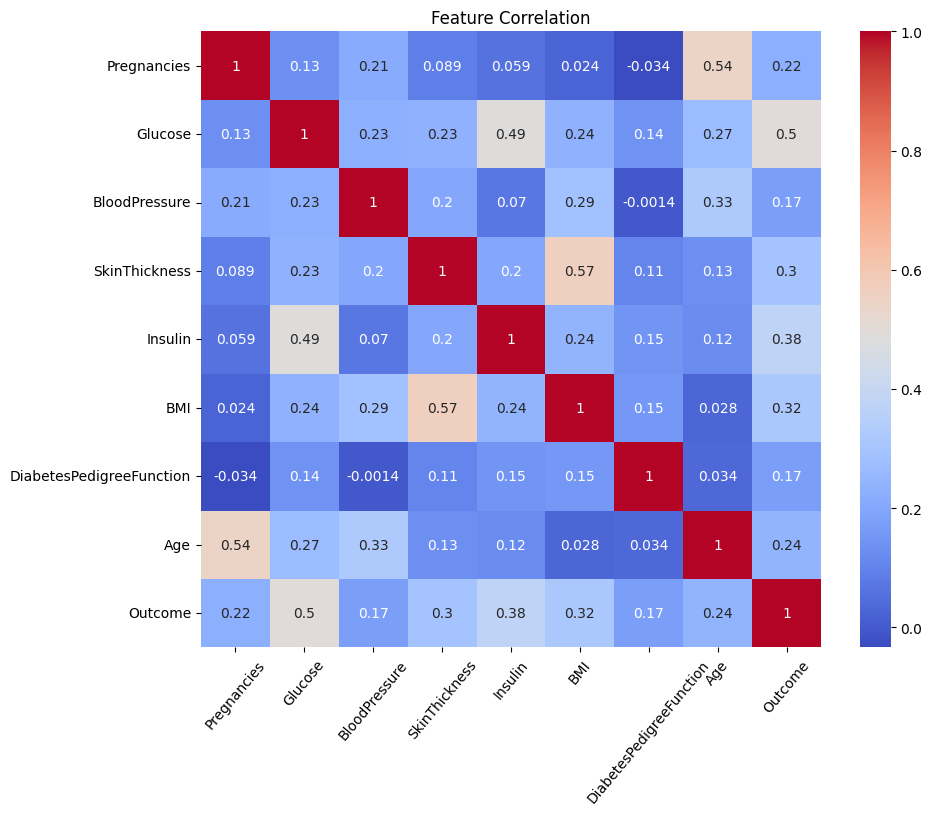

In [13]:
#Correlation Heatmap

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.xticks (rotation=50)
plt.title("Feature Correlation")
plt.show()

correlation insight
- Correlation analysis revealed that Glucose has the strongest positive correlation with the diabetes outcome, followed by BMI and Age. Other features showed weaker relationships with the target variable.

In [14]:
#Grouped Insight
df.groupby("Outcome").mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0.0,3.298000,110.622000,70.844000,27.170000,117.172000,30.846000,0.429734,31.190000
1.0,4.865672,142.302239,75.272388,32.671642,187.615672,35.398507,0.550500,37.067164


Grouped analysis showed that diabetic patients have higher average values for key features such as Glucose, BMI, Insulin, and Age compared to non-diabetic patients. Among these, Glucose and BMI exhibited the most significant differences, indicating their strong influence on diabetes prediction

In [15]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Model Training

In [16]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

## Feature Scaling

In [17]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)


## Training model

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

lr=LogisticRegression()
rf=RandomForestClassifier()

lr.fit(X_train_scaled,y_train)
rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Evaluate model

In [19]:
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

#logistic regression
y_pred_lr=lr.predict(X_test_scaled)

In [20]:
#Random Forest
y_pred_rf=rf.predict(X_test)
print("Logistic regression Accuracy:",accuracy_score(y_test,y_pred_lr))
print("Random Forest Accuracy:",accuracy_score(y_test,y_pred_rf))

Logistic regression Accuracy: 0.7207792207792207
Random Forest Accuracy: 0.8636363636363636


In [21]:

print('\n Classification Report(RF):')
print(classification_report(y_test,y_pred_rf))


 Classification Report(RF):
              precision    recall  f1-score   support

         0.0       0.89      0.90      0.90       100
         1.0       0.81      0.80      0.80        54

    accuracy                           0.86       154
   macro avg       0.85      0.85      0.85       154
weighted avg       0.86      0.86      0.86       154



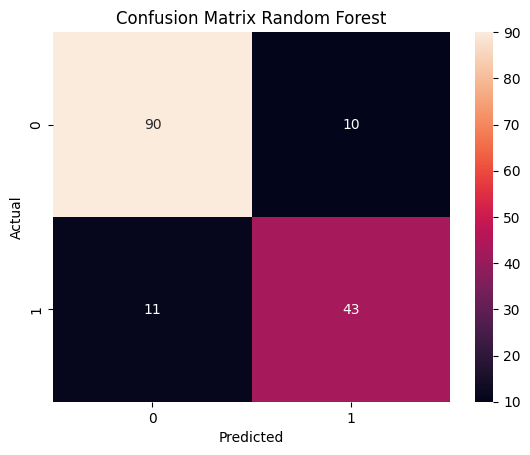

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix : Random Forest")
plt.show()

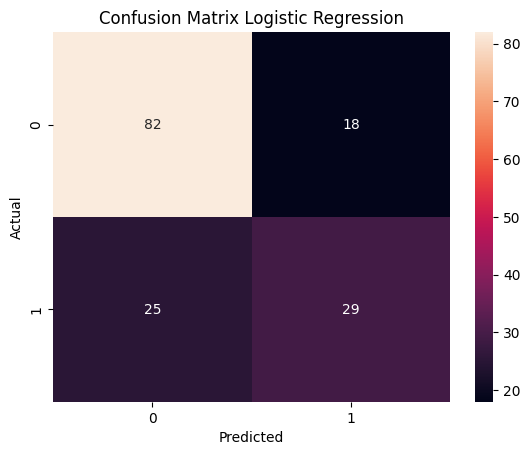

In [ ]:
cm_lr= confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm_lr, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: Logistic Regression")
plt.show()

Model comparison Insight
- Random Forest performed better than Logistic Regression due to its ability to capture non-linear relationships and interactions between features.

## Hyperparameter Tuning


In [27]:
from sklearn.model_selection import GridSearchCV

par_grid={'n_estimators':[100,200],'max_depth':[None,5,10]}

grid=GridSearchCV(RandomForestClassifier(),par_grid,cv=5)

grid.fit(X_train,y_train)

best_model=grid.best_estimator_

In [28]:
print(best_model)

RandomForestClassifier(n_estimators=200)


## Model Save 

In [31]:
import joblib

joblib.dump(best_model,r"D:\my_git\Diabetes_Classification\model\model.pkl")
joblib.dump(scaler,r"D:\my_git\Diabetes_Classification\model\scaler.pkl")


['D:\\my_git\\Diabetes_Classification\\model\\scaler.pkl']